# EXFOR Database API Demo

This notebook demonstrates how to use the `kika.exfor` module to access EXFOR experimental nuclear data.

## What is EXFOR?

EXFOR (Experimental Nuclear Reaction Data) is an international database of experimental nuclear reaction data. It contains measurements from thousands of experiments worldwide, including:
- Angular distributions
- Cross sections
- Energy spectra

## What does kika.exfor provide?

The `kika.exfor` module provides Python access to EXFOR data, with support for:
- **X4Pro Database**: Direct access to 189,000+ datasets from the X4Pro SQLite database
- **JSON Files**: Load from your own curated JSON files
- **Auto mode**: Database with JSON fallback for missing entries

## Quick Start

The simplest way to load EXFOR data:

In [1]:
from kika.exfor import read_all_exfor, X4ProDatabase

# Load all Fe-56 elastic scattering data
data = read_all_exfor(target="Fe56", mt=2)

print(f"Found data at {len(data)} unique energies")
print(f"Energy range: {min(data.keys()):.3f} - {max(data.keys()):.3f} MeV")

Found data at 6258 unique energies
Energy range: 0.010 - 96.000 MeV


## Exploring Available Data

Before loading data, you can browse what's available in the database.

In [2]:
# Connect to the database
db = X4ProDatabase()

# See database statistics
stats = db.get_statistics()
print("Database Statistics:")
for key, value in stats.items():
    print(f"  {key}: {value:,}")

Database Statistics:
  total_datasets: 189,313
  total_metadata: 186,939
  angular_distributions: 48,779
  elastic_scattering: 9,888


In [3]:
# List all targets with angular distribution data for neutrons
targets = db.list_targets(projectile="n")
print(f"\nTotal targets with angular distribution data: {len(targets)}")
print(f"\nFirst 20 targets: {targets[:20]}")


Total targets with angular distribution data: 294

First 20 targets: ['Ac-227', 'Ag-0', 'Ag-107', 'Al-27', 'Am-241', 'Am-242-m', 'Am-243', 'Ar-0', 'Ar-36', 'Ar-40', 'As-75', 'Au-197', 'B-0', 'B-10', 'B-11', 'Ba-0', 'Ba-134', 'Ba-135', 'Ba-136', 'Ba-137']


In [4]:
# List experiments for Fe-56 elastic scattering
experiments = db.list_experiments(target=26056, mt=2)
print(f"Fe-56 elastic scattering experiments: {len(experiments)}")
print()
experiments

Fe-56 elastic scattering experiments: 18



,dataset_id,author,year,energy_min,energy_max
0,20482005,Cabe,1967,0.020000,0.03500
1,20482006,Cabe,1967,0.020000,0.03500
2,11276009,Rodgers,1967,2.330000,2.33000
3,11708006,Kinney,1968,0.030000,0.05000
4,10037024,Boschung,1971,0.010000,0.01000
5,400750022,Morozov,1972,1.800000,1.80000
6,400750021,Morozov,1972,1.800000,1.80000
7,40417003,Tutubalin,1973,14.700000,14.70000
8,30463020,Schweitzer,1978,3.400000,3.40000
9,30463022,Schweitzer,1978,3.400000,3.40000


## Loading Data - Three Ways

### Option 1: From Database (default)

Access the full X4Pro database with 189,000+ datasets.

In [5]:
# Load from database (default)
data = read_all_exfor(target="Fe56", mt=2, source="database")
print(f"From database: {len(data)} energies")

From database: 6258 energies


### Option 2: From JSON Files Only

Load only from your curated JSON files (useful for reproducibility or custom datasets).

In [6]:
# Example: Load only from JSON files
# data = read_all_exfor(source="json", directory="/path/to/your/json/files")
print("To load from JSON files, specify the directory:")
print('  data = read_all_exfor(source="json", directory="/path/to/data/")')

To load from JSON files, specify the directory:
  data = read_all_exfor(source="json", directory="/path/to/data/")


### Option 3: Auto Mode (Database + JSON Fallback)

Combines both sources - uses database but falls back to JSON for missing entries.

In [7]:
# Example: Auto mode with fallback
# data = read_all_exfor(target="Fe56", source="auto", directory="/path/to/data/")
print("Auto mode uses database with JSON fallback:")
print('  data = read_all_exfor(target="Fe56", source="auto", directory="/path/to/data/")')

Auto mode uses database with JSON fallback:
  data = read_all_exfor(target="Fe56", source="auto", directory="/path/to/data/")


## Working with ExforAngularDistribution Objects

Each dataset is an `ExforAngularDistribution` object with useful methods.

In [8]:
# Load a specific experiment
exp = db.load_experiment("10037024")

print(f"Dataset: {exp.entry}{exp.subentry}")
print(f"Label: {exp.label}")
print(f"Target: {exp.target} (ZAID: {exp.zaid})")
print(f"Frame: {exp.angle_frame}")
print(f"Available energies: {exp.energies()} MeV")

Dataset: 10037024
Label: Boschung (1971)
Target: Fe56 (ZAID: 26056)
Frame: LAB
Available energies: [0.01] MeV


In [9]:
# Convert to DataFrame for easy analysis
df = exp.to_dataframe()
print(f"DataFrame shape: {df.shape}")
df.head(10)

DataFrame shape: (19, 4)


,energy,angle,value,error
0,0.01,25.4,1.116,0.023
1,0.01,25.4,1.095,0.024
2,0.01,30.5,0.828,0.018
3,0.01,35.6,0.600,0.013
4,0.01,35.6,0.571,0.013
5,0.01,40.7,0.365,0.009
6,0.01,40.7,0.385,0.009
7,0.01,55.8,0.073,0.003
8,0.01,55.8,0.056,0.002
9,0.01,73.0,0.014,0.001


In [10]:
# Get data at a specific energy
df_energy = exp.to_dataframe(energy=0.01)
print(f"Data at E=0.01 MeV: {len(df_energy)} points")
df_energy

Data at E=0.01 MeV: 19 points


,energy,angle,value,error
0,0.01,25.4,1.116,0.023
1,0.01,25.4,1.095,0.024
2,0.01,30.5,0.828,0.018
3,0.01,35.6,0.600,0.013
4,0.01,35.6,0.571,0.013
5,0.01,40.7,0.365,0.009
6,0.01,40.7,0.385,0.009
7,0.01,55.8,0.073,0.003
8,0.01,55.8,0.056,0.002
9,0.01,73.0,0.014,0.001


## Plotting Angular Distributions

Let's visualize the data to verify it's correct.

In [11]:
import matplotlib.pyplot as plt
import numpy as np

# Pick an energy with multiple experiments
target_energy = 4.0  # MeV

# Load all Fe-56 elastic data
data = read_all_exfor(target="Fe56", mt=2)

# Find experiments at or near this energy
energies = sorted(data.keys())
closest_energy = min(energies, key=lambda e: abs(e - target_energy))
experiments_at_energy = data[closest_energy]

print(f"Energy: {closest_energy:.4f} MeV")
print(f"Number of experiments: {len(experiments_at_energy)}")
for exp in experiments_at_energy:
    print(f"  - {exp.label}")

Energy: 4.0000 MeV
Number of experiments: 1
  - Ramirez (2017)


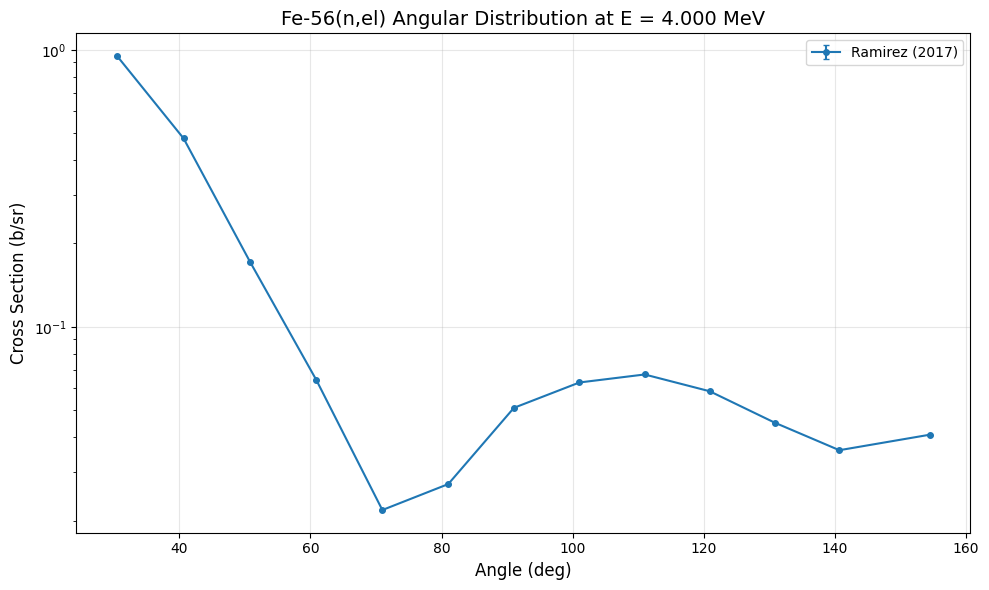

In [12]:
# Plot angular distributions from all experiments at this energy
fig, ax = plt.subplots(figsize=(10, 6))

for exp in experiments_at_energy:
    df = exp.to_dataframe(energy=closest_energy)
    if len(df) > 0:
        ax.errorbar(
            df['angle'], 
            df['value'], 
            yerr=df['error'],
            fmt='o-', 
            label=exp.label,
            capsize=2,
            markersize=4
        )

ax.set_xlabel('Angle (deg)', fontsize=12)
ax.set_ylabel('Cross Section (b/sr)', fontsize=12)
ax.set_title(f'Fe-56(n,el) Angular Distribution at E = {closest_energy:.3f} MeV', fontsize=14)
ax.set_yscale('log')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Experiment: Kinney (1976)
Available energies: 2001


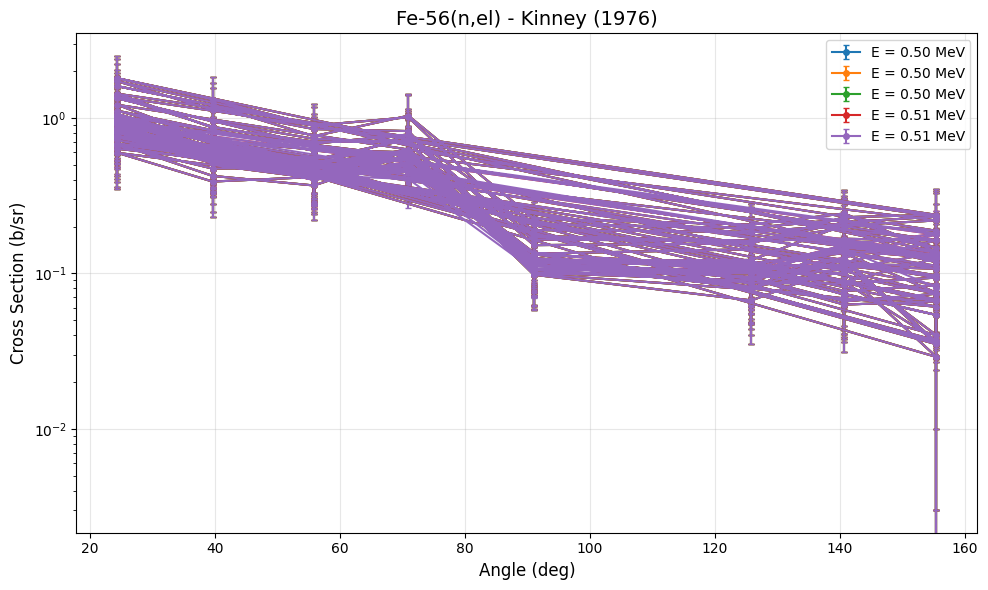

In [13]:
# Plot angular distribution for a single experiment at multiple energies
exp = db.load_experiment("10571002")  # Kinney (1970)
energies = exp.energies()

print(f"Experiment: {exp.label}")
print(f"Available energies: {len(energies)}")

# Pick a few energies to plot
selected_energies = energies[::2][:5]  # Every other energy, up to 5

fig, ax = plt.subplots(figsize=(10, 6))

for e in selected_energies:
    df = exp.to_dataframe(energy=e)
    ax.errorbar(
        df['angle'], 
        df['value'], 
        yerr=df['error'],
        fmt='o-', 
        label=f'E = {e:.2f} MeV',
        capsize=2,
        markersize=4
    )

ax.set_xlabel('Angle (deg)', fontsize=12)
ax.set_ylabel('Cross Section (b/sr)', fontsize=12)
ax.set_title(f'Fe-56(n,el) - {exp.label}', fontsize=14)
ax.set_yscale('log')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary of Key Functions

| Function | Description |
|----------|-------------|
| `read_all_exfor(target="Fe56")` | Load all data for a target |
| `db.list_targets()` | List all available targets |
| `db.list_experiments("Fe56")` | List experiments for a target |
| `db.load_experiment("10037024")` | Load a specific experiment |
| `exp.energies()` | Get available energies |
| `exp.to_dataframe()` | Convert to pandas DataFrame |

### Target Input Formats

The `target` parameter accepts multiple formats:
- `"Fe56"` - Symbol + mass
- `26056` - ZAID (integer)
- `"Fe-56"` - Database format
- `"26-FE-56"` - EXFOR notation

In [16]:
exp.to_dataframe()

,energy,angle,value,error
0,0.5,24.42,0.634,0.275
1,0.5,39.64,0.541,0.231
2,0.5,55.84,0.410,0.170
3,0.5,70.96,0.624,0.260
4,0.5,91.02,0.190,0.078
...,...,...,...,...
16003,2.5,70.96,0.092,0.008
16004,2.5,91.02,0.083,0.007
16005,2.5,125.84,0.124,0.010
16006,2.5,140.66,0.158,0.015


In [15]:
# Close database connection when done
db.close()